In [1]:
import numpy as np
import os 

def return_file_list(filepath = "models", pattern = "results_final"):
    files = os.listdir(filepath)
    files_filtered = [f for f in files if f.startswith(pattern)]
    files_sorted = sorted(files_filtered)
    mod_names = [f for f in os.listdir(filepath) if f.startswith("model_")]
    mod_names_sorted_int = sorted([int(f.split('_')[1][:-4]) for f in mod_names]) 
    return files_sorted, mod_names_sorted_int

# sort by the episode number in the filename that starts after "model_1000_" and ends before ".npy" 
def extract_episode_number(filename):
    return int((filename.split('_')[-2])[:])

#def extract_episode_number(filename):
#    return int((filename.split('_')[-1])[:-4])

def return_final_angles(model_step, files_filtered, filepath = "models_toy"): 

    sorted_ep = sorted([f for f in files_filtered if f"model_{model_step}_" in f and "final" in f], key=extract_episode_number)

    all_data = []
    for s in sorted_ep[:]:
        file = s
        data = np.load(filepath + "/" + file) #, allow_pickle=True)
        all_data.append(data)

    # flatten all_data
    if(len(all_data) > 0):
        all_data = np.concatenate(all_data, axis=0)

    return all_data

def return_action_dicts(files_filtered, model_step, filepath = "models_toy"): 

    sorted_ep = sorted([f for f in files_filtered if f"model_{model_step}_" in f and "action_dict" in f], key=extract_episode_number)

    all_data = []
    for s in sorted_ep[:]:
        file = s
        data = np.load(filepath + "/" + file, allow_pickle=True)
        all_data.append(data)

    return all_data

In [2]:

files_sorted_toy, mod_names_toy = return_file_list("models_toy")

files_sorted, mod_names = return_file_list("models")


all_data = return_final_angles(100000, files_sorted_toy, filepath = "models_toy")
all_data

array([0.20600761, 0.06921896, 0.28461665, 0.1027678 , 0.3598963 ,
       0.10281892, 0.14560445, 0.08477278, 0.08664715, 0.06641486,
       0.06805088, 0.08619137, 0.16714671, 0.23453549, 0.05827557,
       0.09258265, 0.03414645, 0.18744339, 0.17634979, 0.06170157,
       0.08560778, 0.1820915 , 0.08955999, 0.10982294, 0.19733895,
       0.10017525, 0.1726315 , 0.06950621, 0.19860995, 0.0344835 ,
       0.11017369, 0.22473088, 0.15230456, 0.26945564, 0.22690102,
       0.11393588, 0.4792577 , 0.10111611, 0.20555373, 0.23187062,
       0.07720624, 0.23190074, 0.06862002, 0.11405431, 0.09327763,
       0.09471287, 0.08238377, 0.13929074, 0.16939174, 0.28440088,
       0.2867979 , 0.04638059, 0.13463268, 0.10760909, 0.13601904,
       0.2084054 , 0.02849752, 0.05175207, 0.07859407, 0.09836257,
       0.08402612, 0.13570306, 0.1277404 , 0.05300891, 0.1471077 ,
       0.07249399, 0.12958187, 0.19538188, 0.08540959, 0.07966631,
       0.04299425, 0.80241233, 0.09214579, 0.05582529, 0.10550

In [3]:
# save intersection of mod_names and mod_names_toy
mod_names_intersection = list(set(mod_names).intersection(set(mod_names_toy)))

# sort mod_names_intersection by integer value
mod_names_intersection = np.sort(mod_names_intersection)

mod_names_intersection


array([  1000,   5000,  10000,  20000,  40000,  60000, 100000, 200000,
       400000])

In [4]:
files_sorted_toy, mod_names_toy = return_file_list("models_toy", pattern = "action_dict")
all_action_toy = return_action_dicts(files_sorted_toy, 400000, filepath = "models_toy")

files_sorted, mod_names = return_file_list("models", pattern = "action_dict")
all_action = return_action_dicts(files_sorted, 400000, filepath = "models")

In [5]:
#all_actions_n = {k: np.array(v) for k, v in all_action}
action_dict = {}
action_dict_toy = {}
for l in all_action:
    for k, v in l.item().items():
        if k not in action_dict:
            action_dict[k] = []
        action_dict[k].extend(v)

for l in all_action_toy:
    for k, v in l.item().items():
        if k not in action_dict_toy:
            action_dict_toy[k] = []
        action_dict_toy[k].extend(v)
    


In [6]:
all_action_toy[63].item()[0]

[array([-0.89421076, -0.8847631 ], dtype=float32),
 array([ 0.9821708 , -0.47042894], dtype=float32),
 array([-0.9601832 , -0.21153873], dtype=float32),
 array([-0.9460062, -0.3087585], dtype=float32),
 array([ 0.94280386, -0.67339873], dtype=float32),
 array([-0.98330426, -0.88446796], dtype=float32),
 array([ 0.7084514, -0.8469895], dtype=float32),
 array([0.7883072, 0.7320498], dtype=float32),
 array([-0.7579343 , -0.82275355], dtype=float32),
 array([-0.97749525,  0.9605477 ], dtype=float32)]

In [7]:
action_means = []
action_stds = []
action_medians = []
action_means_toy = []
action_stds_toy = []
action_medians_toy = []
for step in range(30):
    a = action_dict[step]
    b = action_dict_toy[step]
    action_means.append(np.mean(np.linalg.norm(a, axis=1)))
    action_stds.append(np.std(np.linalg.norm(a, axis=1)))
    action_medians.append(np.median(np.linalg.norm(a, axis=1)))
    action_means_toy.append(np.mean(np.linalg.norm(b, axis=1)))
    action_stds_toy.append(np.std(np.linalg.norm(b, axis=1)))
    action_medians_toy.append(np.median(np.linalg.norm(b, axis=1)))
    #print(f'Step {step} done')


In [8]:
magnitudes = []
steps = []

magnitudes_toy = []
steps_toy = []

for step in sorted(action_dict.keys()):
    actions_array = action_dict[step]
    mags = np.linalg.norm(actions_array, axis=1)
    magnitudes.append(mags)
    steps.append(step)

for step in sorted(action_dict_toy.keys()):
    actions_array = action_dict_toy[step]
    mags = np.linalg.norm(actions_array, axis=1)
    magnitudes_toy.append(mags)
    steps_toy.append(step)

<ErrorbarContainer object of 3 artists>

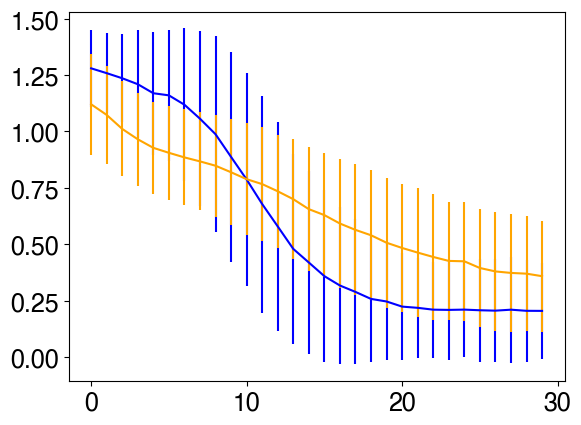

In [72]:
import matplotlib.pyplot as plt
rr = range(30)

plt.errorbar(rr, action_means, yerr=action_stds, label='Mean', color='blue')
plt.errorbar(rr, action_means_toy, yerr=action_stds_toy, label='Mean (toy)', color='orange')
#plt.plot(rr, action_medians, label='Median', color='green')

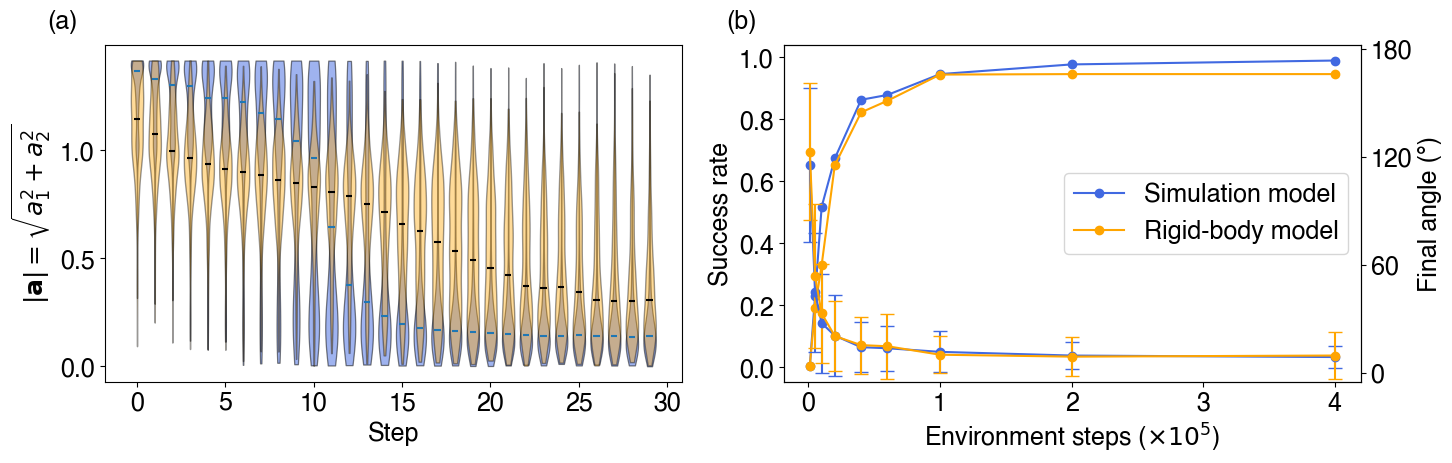

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

font_dir = os.path.expanduser("~/.local/share/fonts")
fm.fontManager.addfont(os.path.join(font_dir, "Helvetica.ttf"))

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 18,
    "axes.labelsize": 18
})

# Compute action magnitudes for each step
magnitudes = []
steps = []

for step in sorted(action_dict.keys()):
    actions_array = action_dict[step]
    mags = np.linalg.norm(actions_array, axis=1)
    magnitudes.append(mags)
    steps.append(step)

# Create two subplots in one row
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ---------------- Left subplot ----------------
vp = ax[0].violinplot(
    magnitudes,
    positions=steps,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    widths=0.7#,
    #label="Simulation model"
)

color = "royalblue"
for body in vp["bodies"]:
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.5)
    body.set_linewidth(0.9)

vp2 = ax[0].violinplot(
    magnitudes_toy,
    positions=steps_toy,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    widths=0.7#,
    #label="Rigid-body model"
)

vp2['cmedians'].set_color('black')

for body in vp2["bodies"]:
    body.set_facecolor("orange")
    body.set_edgecolor("black")
    body.set_alpha(0.4)
    body.set_linewidth(1.0)

ax[0].set_xlabel("Step")
ax[0].set_ylabel(r"$|\mathbf{a}|=\sqrt{a_1^2+a_2^2}$")
#ax[0].grid(alpha=0.3)

# ---------------- Right subplot ----------------
#ax[1].plot(
#    np.array(list(final_angles.keys())) / 100,
#    succes,
#    marker="o",
#    color="royalblue"
#)


ax[1].plot(mod_names_intersection/100000, counts, 'o-', label='Simulation model', color='royalblue')
ax[1].plot(mod_names_intersection/100000, counts_toy, 'o-', label='Rigid-body model', color='orange')

ax[1].set_xlabel("Environment steps ($\\times 10^5$)")
ax[1].set_ylabel("Success rate")
#ax[1].grid(alpha=0.3)

# add (a) and (b) labels to the subplots
ax[0].text(-0.1, 1.05, "(a)", transform=ax[0].transAxes, fontsize=18, fontweight='bold')
ax[1].text(-0.1, 1.05, "(b)", transform=ax[1].transAxes, fontsize=18, fontweight='bold')


# Right y-axis
ax2 = ax[1].twinx()


#ax2.errorbar(np.array(list(final_angles.keys())) / 100, mean_final, yerr=std_final, fmt='-o', color='red', ecolor='black', 
#elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgecolor='black', markeredgewidth=1.5)


ax2.errorbar(mod_names_intersection/100000, np.array(ave_final)/np.pi*180, yerr=np.array(std_final)/np.pi*180, fmt='-o', capsize=5, label='Simulation model', color='royalblue')
ax2.errorbar(mod_names_intersection/100000, np.array(ave_final_toy)/np.pi*180, yerr=np.array(std_final_toy)/np.pi*180, fmt='-o', capsize=5, label='Rigid-body model', color='orange')


ax2.set_ylabel("Final angle (°)") #, color="crimson")
ax2.tick_params(axis="y")#, labelcolor="crimson")
ax2.set_ylim(-5,182)
#ax2.set_ylim(0,20)
# ticks to 0, 60, 120, 180
ax2.set_yticks([0, 60, 120, 180])

#ax[1].legend(loc="upper left")
ax[1].legend(loc="center right")
#ax[0].legend(loc="upper right")
# Adjust spacing
plt.tight_layout()

# Save the combined figure
plt.savefig("action_magnitude_and_success_rate_model_vs_sim.png", dpi=300, bbox_inches="tight")

plt.show()

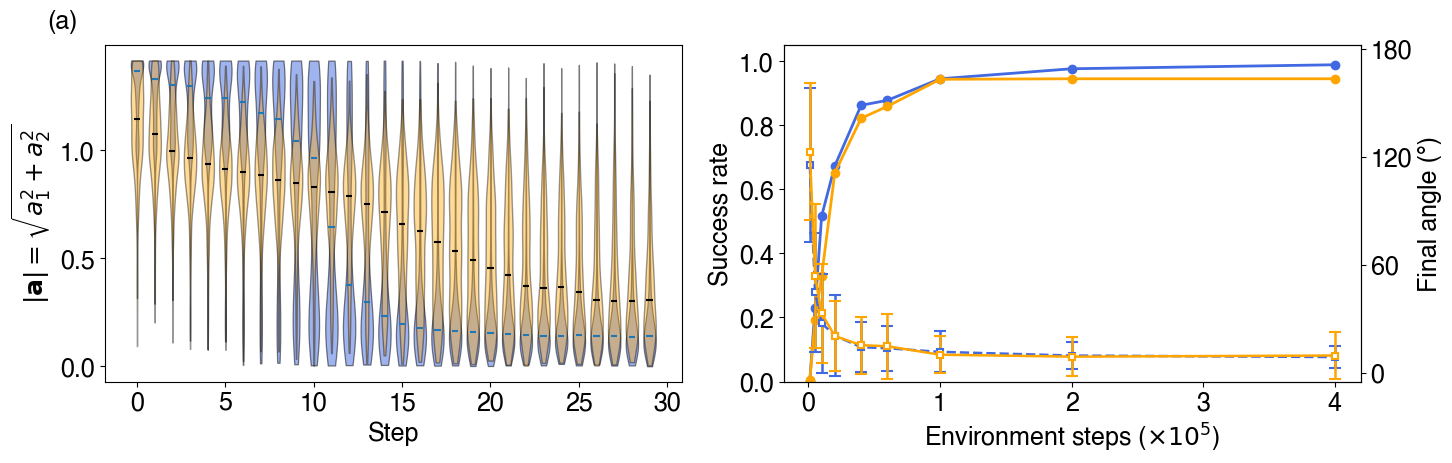

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

font_dir = os.path.expanduser("~/.local/share/fonts")
fm.fontManager.addfont(os.path.join(font_dir, "Helvetica.ttf"))

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 18,
    "axes.labelsize": 18
})

# Compute action magnitudes for each step
magnitudes = []
steps = []

for step in sorted(action_dict.keys()):
    actions_array = action_dict[step]
    mags = np.linalg.norm(actions_array, axis=1)
    magnitudes.append(mags)
    steps.append(step)

# Create two subplots in one row
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ---------------- Left subplot ----------------
vp = ax[0].violinplot(
    magnitudes,
    positions=steps,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    widths=0.7#,
    #label="Simulation model"
)

color = "royalblue"
for body in vp["bodies"]:
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.5)
    body.set_linewidth(0.9)

vp2 = ax[0].violinplot(
    magnitudes_toy,
    positions=steps_toy,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    widths=0.7#,
    #label="Rigid-body model"
)

vp2['cmedians'].set_color('black')

for body in vp2["bodies"]:
    body.set_facecolor("orange")
    body.set_edgecolor("black")
    body.set_alpha(0.4)
    body.set_linewidth(1.0)

ax[0].set_xlabel("Step")
ax[0].set_ylabel(r"$|\mathbf{a}|=\sqrt{a_1^2+a_2^2}$")
#ax[0].grid(alpha=0.3)

# ---------------- Right subplot ----------------
#ax[1].plot(
#    np.array(list(final_angles.keys())) / 100,
#    succes,
#    marker="o",
#    color="royalblue"
#)


# add (a) and (b) labels to the subplots
ax[0].text(-0.1, 1.05, "(a)", transform=ax[0].transAxes, fontsize=18, fontweight='bold')



# ---------------- Right subplot ----------------

x = mod_names_intersection / 100000

# Colors = model
sim_color = "royalblue"
toy_color = "orange"

# Success rate: circles + solid lines
ax[1].plot(
    x, counts,
    marker="o",
    linestyle="-",
    color=sim_color,
    linewidth=2,
    markersize=6,
    label="Simulation model"
)

ax[1].plot(
    x, counts_toy,
    marker="o",
    linestyle="-",
    color=toy_color,
    linewidth=2,
    markersize=6,
    label="Rigid-body model"
)

ax[1].set_xlabel("Environment steps ($\\times 10^5$)")
ax[1].set_ylabel("Success rate")
ax[1].set_ylim(0, 1.05)  # if success rate is 0–1

# Final angle: squares + dashed lines
ax2 = ax[1].twinx()

ax2.errorbar(
    x,
    np.array(ave_final) / np.pi * 180,
    yerr=np.array(std_final) / np.pi * 180,
    fmt="s-",
    color=sim_color,
    linewidth=1.8,
    markersize=5,
    capsize=4,
    markerfacecolor="white",
    markeredgewidth=1.5,
)

ax2.errorbar(
    x,
    np.array(ave_final_toy) / np.pi * 180,
    yerr=np.array(std_final_toy) / np.pi * 180,
    fmt="s-",
    color=toy_color,
    linewidth=1.8,
    markersize=5,
    capsize=4,
    markerfacecolor="white",
    markeredgewidth=1.5,
)

ax2.set_ylabel("Final angle (°)")
ax2.set_ylim(-5, 182)
ax2.set_yticks([0, 60, 120, 180])

#ax[0].legend(loc="upper right")
# Adjust spacing
plt.tight_layout()

# Save the combined figure
plt.savefig("action_magnitude_and_success_rate_model_vs_sim.png", dpi=300, bbox_inches="tight")

plt.show()



In [47]:
np.array(ave_final)/np.pi*180, np.array(std_final)/np.pi*180


(array([115.43584 ,  44.530148,  27.462229,  20.526407,  14.0901  ,
         13.503385,  11.497632,   9.443916,   8.609083], dtype=float32),
 array([42.69574  , 33.046833 , 27.4507   , 22.347662 , 13.983354 ,
        12.460236 , 11.354181 ,  7.325644 ,  6.2025995], dtype=float32))

In [48]:
np.array(ave_final_toy)/np.pi*180, np.array(std_final_toy)/np.pi*180

(array([122.84912 ,  53.689274,  32.841324,  20.28792 ,  15.238995,
         14.613831,   9.907333,   8.832754,   9.456753], dtype=float32),
 array([38.017715, 40.124123, 27.535057, 19.28252 , 15.786297, 18.000156,
        10.286161, 10.875029, 13.041501], dtype=float32))

In [10]:
files_sorted_toy, mod_names_toy = return_file_list("models_toy", pattern = "results_final")
files_sorted, mod_names = return_file_list("models", pattern="results_final")
mod_names_intersection = list(set(mod_names).intersection(set(mod_names_toy)))
mod_names_intersection = np.sort(mod_names_intersection)

ave_final = []
std_final = []
counts = []
ave_final_toy = []
std_final_toy = []
counts_toy = []
for mod in mod_names_intersection:
    all_data = return_final_angles(mod, files_sorted, filepath = "models")
    all_data_toy = return_final_angles(mod, files_sorted_toy, filepath = "models_toy")
    ave_final_toy.append(np.mean(all_data_toy))
    std_final_toy.append(np.std(all_data_toy))
    ave_final.append(np.mean(all_data))
    std_final.append(np.std(all_data))
    cnt = len(all_data[all_data < 20/180*np.pi])/len(all_data)
    cnt_toy = len(all_data_toy[all_data_toy < 20/180*np.pi])/len(all_data_toy)
    counts.append(cnt)
    counts_toy.append(cnt_toy)
    print(f"Model {mod}: mean = {ave_final[-1]}, std = {std_final[-1]}, count < 20 deg = {cnt}")
    print(f"Model {mod} (toy): mean = {ave_final_toy[-1]}, std = {std_final_toy[-1]}, count < 20 deg = {cnt_toy}")

Model 1000: mean = 2.014735460281372, std = 0.7451812624931335, count < 20 deg = 0.003125
Model 1000 (toy): mean = 2.1441216468811035, std = 0.6635342836380005, count < 20 deg = 0.0046875
Model 5000: mean = 0.7771977186203003, std = 0.5767760872840881, count < 20 deg = 0.2296875
Model 5000 (toy): mean = 0.9370546340942383, std = 0.7002980709075928, count < 20 deg = 0.1921875
Model 10000: mean = 0.47930631041526794, std = 0.479105144739151, count < 20 deg = 0.5171875
Model 10000 (toy): mean = 0.5731892585754395, std = 0.48057740926742554, count < 20 deg = 0.3296875
Model 20000: mean = 0.3582534193992615, std = 0.3900402784347534, count < 20 deg = 0.6734375
Model 20000 (toy): mean = 0.35409098863601685, std = 0.336543470621109, count < 20 deg = 0.6515625
Model 40000: mean = 0.2459186315536499, std = 0.24405556917190552, count < 20 deg = 0.8625
Model 40000 (toy): mean = 0.2659706473350525, std = 0.2755228579044342, count < 20 deg = 0.821875
Model 60000: mean = 0.2356785237789154, std = 0.

In [22]:
all_data = return_final_angles(1000, files_sorted, filepath = "models")

In [23]:
all_data

[]

Text(-0.1, 1.05, '(b)')

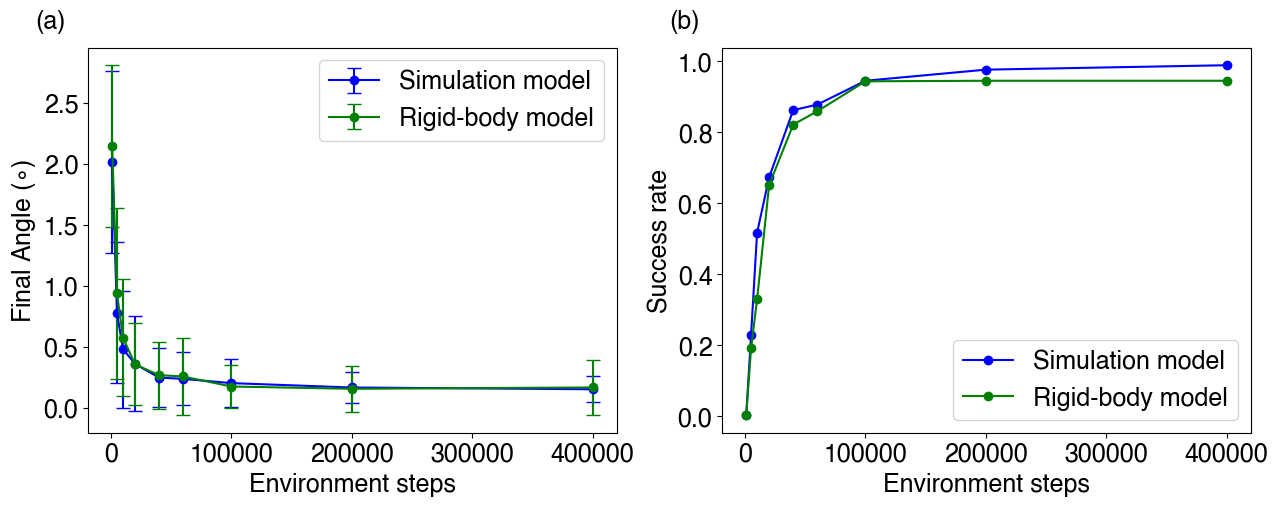

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

font_dir = os.path.expanduser("~/.local/share/fonts")
fm.fontManager.addfont(os.path.join(font_dir, "Helvetica.ttf"))

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 18,
    "axes.labelsize": 18
})


# Create two subplots in one row
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].errorbar(mod_names_intersection, ave_final, yerr=std_final, fmt='-o', capsize=5, label='Simulation model', color='blue')
ax[0].errorbar(mod_names_intersection, ave_final_toy, yerr=std_final_toy, fmt='-o', capsize=5, label='Rigid-body model', color='green')
ax[0].set_xlabel('Environment steps')
ax[0].set_ylabel(r'Final Angle ($\circ$)')

# ticks for x-axis should be 1e5, 2e5 ...

#ax[0].set_title('Final Angles vs Model Step')
ax[0].legend()

ax[1].plot(mod_names_intersection, counts, 'o-', label='Simulation model', color='blue')
ax[1].plot(mod_names_intersection, counts_toy, 'o-', label='Rigid-body model', color='green')
ax[1].set_xlabel('Environment steps')
ax[1].set_ylabel('Success rate')
#ax[1].set_title('Count of Final Angles < 20 deg vs Model Step')
ax[1].legend()

ax[0].text(-0.1, 1.05, "(a)", transform=ax[0].transAxes, fontsize=18, fontweight='bold')
ax[1].text(-0.1, 1.05, "(b)", transform=ax[1].transAxes, fontsize=18, fontweight='bold')




In [8]:
mod_names, ave_final, std_final

([100,
  1000,
  2000,
  5000,
  10000,
  20000,
  40000,
  60000,
  100000,
  200000,
  300000,
  400000,
  500000],
 [np.float32(2.2008305),
  np.float32(2.1441216),
  np.float32(1.849036),
  np.float32(0.93705463),
  np.float32(0.57318926),
  np.float32(0.354091),
  np.float32(0.37396437),
  np.float32(1.5481069),
  np.float32(1.2324038),
  np.float32(2.601578),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan)],
 [np.float32(0.6442685),
  np.float32(0.6635343),
  np.float32(0.75816303),
  np.float32(0.7002981),
  np.float32(0.4805774),
  np.float32(0.33654347),
  np.float32(0.56249744),
  np.float32(1.2504151),
  np.float32(1.2749395),
  np.float32(0.5770138),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan)])